# ResNet testing figures

In [1]:
import csv
import json
import re
import sys
import time
import os
import numpy as np
import torch
from pathlib import Path
from argparse import ArgumentParser


In [2]:
evaluation_id = "03-10_dataset_size_4_class"
fetch_type = "evaluation_id"

results_dict = {
    "xpaste":{
        "no_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_no_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
            },
        "real_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_real_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        },
        "synth_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_synth_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        },
        "real_synth_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_real_synth_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        }
    },
    "diffusion": {
        "no_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/diffusion_4-class_128_splits_no_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        },
        "real_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/diffusion_4-class_128_splits_real_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        },
        "synth_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/diffusion_4-class_128_splits_synth_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        },
        "real_synth_aug": {
            "path": "/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/diffusion_4-class_128_splits_real_synth_aug/results.json",
            "x": [],
            "y": [],
            "y_std": []
        }
    }
}
# config_path = "/home/ap/cloud/Master/aris_master/testing/02-19_normal-wood_impregnated-wood_1024_splits_final/config.json"

test_folder_path = "../../testing"

In [3]:
def fetch_results_by_evaluation_id(evaluation_id, base_folder=test_folder_path, json_filename = "results.json", force=False):
    """
    Find all 'results.json' files under base_folder and ensure each file contains
    a 'unique_evaluation_id' equal to the provided evaluation_id.

    Returns:
        list[Path]: Paths to matching results.json files.

    Raises:
        FileNotFoundError: If no results.json files are found.
        ValueError: If a file is missing 'unique_evaluation_id' or has a mismatched value.
        json.JSONDecodeError: If a results.json file is invalid JSON.
    """
    base_path = Path(base_folder)
    results_files = list(base_path.rglob(json_filename))

    if not results_files:
        raise FileNotFoundError(f"No '{json_filename}' files found in: {base_path}")

    matching_files = []

    for file_path in results_files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        if "evaluation_id" not in data and not force:
            print(f"Skipping {file_path} due to missing 'evaluation_id'")
            continue
        
        if not force:
            if data["evaluation_id"] != evaluation_id:
                print(f"Skipping {file_path} due to mismatched evaluation_id: {data['evaluation_id']}")
                continue
    

        matching_files.append(file_path)

    return matching_files


In [23]:
if fetch_type == "results":
    # Fetch config files matching the evaluation_id
    print(results_dict)
    for method, aug_dict in results_dict.items():
        for aug_type, result_info in aug_dict.items():
            result_file_path = Path(result_info["path"])
            # Check if file exists            
            if not result_file_path.is_file():
                print(f"File not found: {result_file_path}")
                continue
            with result_file_path.open("r", encoding="utf-8") as f:
                data = json.load(f)
            
            x = []
            y = []
            y_std = []
            for entry in data["splits"]:
                val_acc = []
                f1_score = []
                for run in entry["runs"]:
                    val_acc.append(run["val_accuracy"])
                    #f1_score.append(run["f1_score"])
                # Calculate mean and std for val_acc and f1_score
                x.append(entry["synthetic_image_count"])
                y.append(np.mean(val_acc))
                y_std.append(np.std(val_acc))
                # f1_score_mean = np.mean(f1_score)
                # f1_score_std = np.std(f1_score)
                # Sort y values based on x (synthetic_image_count)
                # Ensure iterables before zipping/sorting (x, y, y_std are scalars per split)


            xy_sorted = sorted(zip(x, y), key=lambda t: t[0])
            x_sorted, y_sorted = map(list, zip(*xy_sorted))
            print(f"{method} - {aug_type}")
            print(f"x: {x_sorted}")
            print(f"y: {y_sorted}")

            # If using mean/std:
            xyz_sorted = sorted(zip(x, y, y_std), key=lambda t: t[0])
            x_sorted, y_sorted, y_std_sorted = map(list, zip(*xyz_sorted))
            y_sorted = [float(100*y) for y in y_sorted]
            y_std_sorted = [float(100*y) for y in y_std_sorted]

            results_dict[method][aug_type]["x"] = x_sorted
            results_dict[method][aug_type]["y"] = y_sorted
            results_dict[method][aug_type]["y_std"] = y_std_sorted
elif fetch_type == "evaluation_id":
    # Fetch results files matching the evaluation_id
    y_list = fetch_results_by_evaluation_id(evaluation_id, test_folder_path)
    print(y_list)
    y_mean = []
    y_std = []
    x = []
    for result_file in y_list:
        with result_file.open("r", encoding="utf-8") as f:
            data = json.load(f)

        for entry in data["splits"]:
            val_acc = []
            f1_score = []
            for run in entry["runs"]:
                val_acc.append(run["val_accuracy"])
                #f1_score.append(run["f1_score"])
            # Calculate mean and std for val_acc and f1_score
            val_acc_mean = np.mean(val_acc)
            val_acc_std = np.std(val_acc)
            f1_score_mean = np.mean(f1_score)

            f1_score_std = np.std(f1_score)
            y_mean.append(float(val_acc_mean))
            y_std.append(float(val_acc_std))
            x.append(entry["real_image_count"])
            xyz_sorted = sorted(zip(x, y_mean, y_std), key=lambda t: t[0])
            
    xyz_sorted = sorted(zip(x, y_mean, y_std), key=lambda t: t[0])
    x_sorted, y_sorted, y_std_sorted = map(list, zip(*xyz_sorted))
    y_sorted = [float(100*y) for y in y_sorted]
    # Round y_sorted to 2 decimal places
    y_sorted = [round(y, 2) for y in y_sorted]
    y_std_sorted = [float(100*y) for y in y_std_sorted]

x_sorted = [x//4 for x in x_sorted]
print(x_sorted)
print(y_sorted)
print(y_std_sorted)
print(results_dict)

[PosixPath('../../testing/03-10_dataset_size_4_class/synth_0/results.json')]
[5, 10, 25, 50, 100, 200, 250, 500, 1000]
[66.9, 73.4, 75.5, 82.27, 85.48, 89.07, 89.91, 91.17, 92.65]
[5.349361726619562, 2.1672661719318165, 3.6430893349219695, 1.9642645482611447, 0.7015913482932915, 0.688505300552499, 0.656520164706818, 0.3315485786427059, 0.8847032044702894]
{'xpaste': {'no_aug': {'path': '/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_no_aug/results.json', 'x': [], 'y': [], 'y_std': []}, 'real_aug': {'path': '/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_real_aug/results.json', 'x': [], 'y': [], 'y_std': []}, 'synth_aug': {'path': '/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_synth_aug/results.json', 'x': [], 'y': [], 'y_std': []}, 'real_synth_aug': {'path': '/home/ap/cloud/master/aris_master/testing/02-27_xpaste_vs_diffusionV1/XPASTE_4_class_real_synth_aug/results.json', 

/home/simon/master2025dev/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/simon/master2025dev/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/simon/master2025dev/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/simon/master2025dev/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/simon/master2025dev/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret /

In [11]:
def bar_chart_with_error_bars(x, y_mean, y_std):
    import matplotlib.pyplot as plt
    import numpy as np

    x_pos = np.arange(len(x))

    bars = plt.bar(
        x_pos, y_mean, yerr=y_std, align='center',
        alpha=0.7, ecolor='black', capsize=10
    )
    plt.xticks(x_pos, x)
    plt.xlabel('Resolution')
    plt.ylabel('Mean Accuracy')
    plt.title('Mean Accuracy by Resolution')
    plt.grid(axis='y')

    # Add accuracy value on top of each bar
    y_max = max(m + s for m, s in zip(y_mean, y_std))
    plt.ylim(0, y_max + 0.05)
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2 + 0.27,
            height  + 0,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

bar_chart_with_error_bars(x_sorted, y_mean_sorted, y_std_sorted)

NameError: name 'y_mean_sorted' is not defined

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

for method, aug_dict in results_dict.items():
    for aug_type, vals in aug_dict.items():
        # Check if path exists and has data
        if not vals:
            print(f"Skipping {method} / {aug_type}: no data")
            continue
        
        x_vals = vals.get("x", [])
        y_vals = vals.get("y", [])
        y_err = vals.get("y_std", [])
        print(f"{method} - {aug_type}: x={x_vals}, y={y_vals}, y_err={y_err}")
        if x_vals == [] or y_vals == [] or np.any(np.isnan(y_vals)):
            print(f"Skipping {method} / {aug_type}: no data")
            continue

        if not x_vals or not y_vals:
            print(f"Skipping {method} / {aug_type}: no data")
            continue

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.errorbar(
            x_vals,
            y_vals,
            yerr=y_err if y_err else None,
            fmt="o-",
            linewidth=2,
            capsize=5,
            ecolor="black"
        )

        ax.set_xlabel("Synthetic image count")
        ax.set_ylabel("Mean Accuracy (%)")
        ax.set_title(f"Mean Accuracy vs Synthetic Count | {method} | {aug_type}")

        ax.set_xscale("linear")
        ax.set_xticks(x_vals)
        ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
        ax.grid(True, axis="both", alpha=0.3)
        ax.set_axisbelow(True)

        if y_err:
            y_min = min(y - e for y, e in zip(y_vals, y_err))
            y_max = max(y + e for y, e in zip(y_vals, y_err))
        else:
            y_min = min(y_vals)
            y_max = max(y_vals)

        for xi, yi in zip(x_vals, y_vals):
            ax.text(xi, yi + 0.2, f"{yi:.2f}", ha="center", fontsize=9)

        pad = max(0.5, (y_max - y_min) * 0.1)
        ax.set_ylim(y_min - pad, y_max + pad)

        plt.tight_layout()
        plt.savefig(f"accuracy_{method}_{aug_type}.png", dpi=400)
        plt.show()

xpaste - no_aug: x=[], y=[], y_err=[]
Skipping xpaste / no_aug: no data
xpaste - real_aug: x=[], y=[], y_err=[]
Skipping xpaste / real_aug: no data
xpaste - synth_aug: x=[], y=[], y_err=[]
Skipping xpaste / synth_aug: no data
xpaste - real_synth_aug: x=[], y=[], y_err=[]
Skipping xpaste / real_synth_aug: no data
diffusion - no_aug: x=[], y=[], y_err=[]
Skipping diffusion / no_aug: no data
diffusion - real_aug: x=[], y=[], y_err=[]
Skipping diffusion / real_aug: no data
diffusion - synth_aug: x=[], y=[], y_err=[]
Skipping diffusion / synth_aug: no data
diffusion - real_synth_aug: x=[], y=[], y_err=[]
Skipping diffusion / real_synth_aug: no data


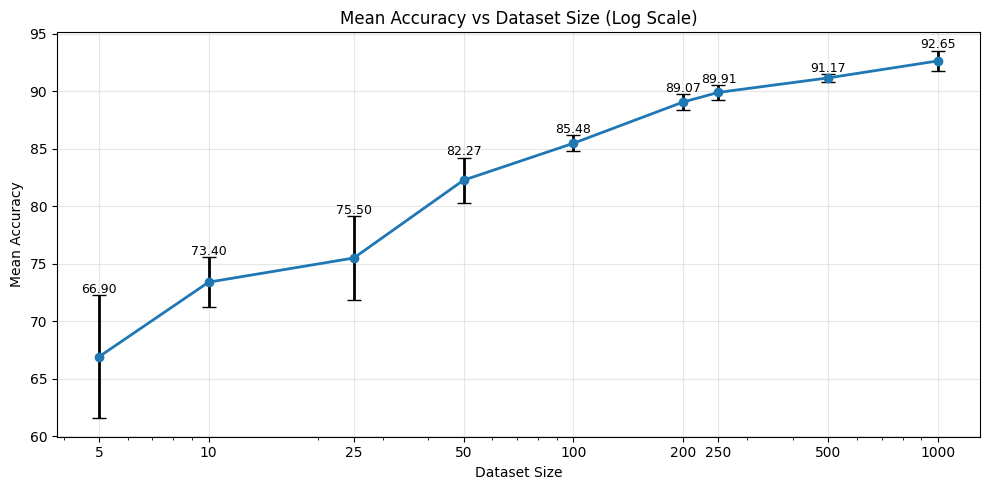

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x_sorted,
    y_sorted,
    yerr=y_std_sorted,
    fmt='o-',
    linewidth=2,
    capsize=5,
    ecolor='black'
)

ax.set_xlabel("Dataset Size")
ax.set_ylabel("Mean Accuracy")
ax.set_title("Mean Accuracy vs Dataset Size (Log Scale)")

ax.set_xscale("log")
ax.set_xticks(x_sorted)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

ax.grid(True, axis="both", alpha=0.3)
ax.set_axisbelow(True)

for xi, yi, ei in zip(x_sorted, y_sorted, y_std_sorted):
    ax.text(xi, yi + ei + 0.2, f"{yi:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## Accuracy normalized by memory usage

NameError: name 'x_scale' is not defined

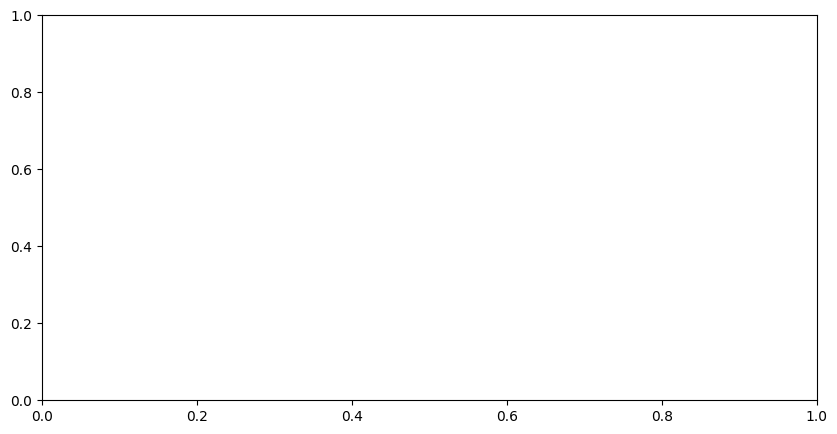

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_sorted, x_scale, 'o-', linewidth=2)

ax.set_xlabel("Resolution (px)")
ax.set_ylabel("Relative Memory Usage")
ax.set_title("Relative Memory Usage vs Resolution")

ax.set_xscale("linear")
ax.set_xticks(x_sorted)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

ax.grid(True, axis="both", alpha=0.3)
ax.set_axisbelow(True)

for xi, yi, scale in zip(x_sorted, y_memory_normalized, x_scale):
    ax.text(xi, scale +4, f"{scale:.2f}", ha="center", fontsize=9)

#ax.set_ylim(min(y_memory_normalized) - max(y_memory_normalized) * 0.05, max(y_memory_normalized) * 1.1)
plt.tight_layout()
plt.show()
